In [1]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.image import resize
from tensorflow.keras.optimizers import Adam

import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# Cargar datos de MNIST y hacer una reducción de los tamaños
(x_train, y_train), (x_test, y_test) = mnist.load_data()  #fashion_mnist.load_data()

# Reducir el conjunto de entrenamiento y prueba de manera estratificada
train_size = 0.1  # Proporción del conjunto de entrenamiento
test_size = 0.1   # Proporción del conjunto de prueba

# Dividir entrenamiento (estratificado)
x_train_reduced, _, y_train_reduced, _ = train_test_split(
    x_train, y_train, train_size=train_size, stratify=y_train, random_state=42
)

# Dividir testeo (estratificado)
x_test_reduced, _, y_test_reduced, _ = train_test_split(
    x_test, y_test, train_size=test_size, stratify=y_test, random_state=42
)

print("Tamaño reducido de entrenamiento:", x_train_reduced.shape[0])
print("Tamaño reducido de prueba:", x_test_reduced.shape[0])

x_train = x_train_reduced
y_train = y_train_reduced
x_test = x_test_reduced
y_test = y_test_reduced


# Inspeccionar las dimensiones de los datos
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Tamaño reducido de entrenamiento: 6000
Tamaño reducido de prueba: 1000
x_train shape: (6000, 28, 28)
y_train shape: (6000,)
x_test shape: (1000, 28, 28)
y_test shape: (1000,)


In [3]:
# preprocesar MNIST
x_train = np.stack([x_train]*3, axis=-1) / 255.0  # Convertir a 3 canales
x_test = np.stack([x_test]*3, axis=-1) / 255.0
x_train = resize(x_train, (96, 96))  # Redimensionar a 96x96
x_test = resize(x_test, (96, 96))

# One-hot encoding de las etiquetas
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [4]:
# Cargar MobileNetV2 preentrenada en ImageNet
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

# Contar el número de capas
print(f"Total de capas en MobileNetV2: {len(base_model.layers)}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total de capas en MobileNetV2: 154


In [5]:
# Desbloquear las últimas capas del modelo base
base_model.trainable = True

# Congelar las primeras capas
for layer in base_model.layers[:100]:
    layer.trainable = False

# Crear modelo completo
inputs = Input(shape=(96, 96, 3))
# solo se van a actualizar los pesos de las últimas 54 capas del modelo base
x = base_model(inputs, training=True)  # Fine-tuning habilitado
x = Flatten()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 11520)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11520)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,474,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,733,962 (14.24 MB)

 Trainable params: 3,337,418 (12.73 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [6]:
# Compilar nuevamente con un menor learning rate
model.compile(optimizer=Adam(1e-5),  # Menor tasa de aprendizaje
              loss='categorical_crossentropy', metrics=['accuracy'])

# Continuar el entrenamiento con fine-tuning
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_test, y_test))


Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 45s 103ms/step - accuracy: 0.2553 - loss: 2.6812 - val_accuracy: 0.4740 - val_loss: 1.5781
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7289 - loss: 0.8517 - val_accuracy: 0.6960 - val_loss: 1.0138
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8575 - loss: 0.4537 - val_accuracy: 0.7990 - val_loss: 0.6729
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9001 - loss: 0.3212 - val_accuracy: 0.8690 - val_loss: 0.4579
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9251 - loss: 0.2325 - val_accuracy: 0.9030 - val_loss: 0.3253
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9454 - loss: 0.1649 - val_accuracy: 0.9300 - val_loss: 0.2424
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9526 - loss: 0.1430 - val_accuracy: 0.9460 - val_loss: 0.1874
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9688 - loss: 0.0951 - val_a

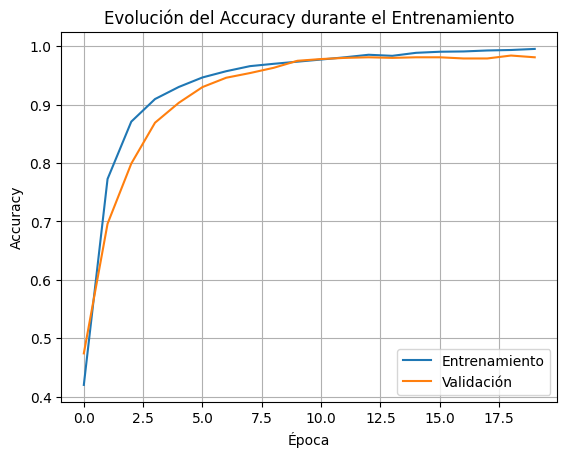

In [7]:
# Graficar el Accuracy
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Evolución del Accuracy durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()